In [1]:
import pandas as pd
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix
import time
import re
import warnings
warnings.filterwarnings('ignore')

performance = pd.DataFrame(columns=['Name', 'Accuracy', 'Precision', 'Sensitivity', 'F1 Score', 'MCC', 'Markedness', "Youden's J", 'FMI', 'Time'])

df = pd.read_csv("StealthPhisher_V6.csv")

LABEL = df.iloc[:,-1:].columns[0]

fs = ['LengthOfURL', 'URLComplexity', 'CharacterComplexity',
       'DomainLengthOfURL', 'IsDomainIP', 'TLDLength', 'LetterCntInURL',
       'URLLetterRatio', 'DigitCntInURL', 'URLDigitRatio', 'EqualCharCntInURL',
       'QuesMarkCntInURL', 'AmpCharCntInURL', 'OtherSpclCharCntInURL',
       'URLOtherSpclCharRatio', 'NumberOfHashtags', 'NumberOfSubdomains',
       'HavingPath', 'Path Length', 'HavingQuery', 'HavingFragment',
       'HavingAnchor', 'HasSSL', 'IsUnreachable', 'LineOfCode',
       'LongestLineLength', 'HasTitle', 'TitleMatchScore', 'HasFavicon',LABEL]

df = pd.DataFrame(df[fs]).copy()
print('Dataset Shape: ', df.shape)
df.iloc[:,-1:].value_counts()

FileNotFoundError: [Errno 2] No such file or directory: 'StealthPhisher_V6.csv'

Epoch 1/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9564 - loss: 0.2645 - val_accuracy: 0.9858 - val_loss: 0.0620
Epoch 2/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9867 - loss: 0.0513 - val_accuracy: 0.9875 - val_loss: 0.0376
Epoch 3/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9877 - loss: 0.0354 - val_accuracy: 0.9891 - val_loss: 0.0307
Epoch 4/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9881 - loss: 0.0311 - val_accuracy: 0.9887 - val_loss: 0.0310
Epoch 5/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9888 - loss: 0.0297 - val_accuracy: 0.9901 - val_loss: 0.0280
Epoch 6/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9894 - loss: 0.0281 - val_accuracy: 0.9900 - val_loss: 0.0266
Epoch 7/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9898 - loss: 0.0271 - val_accuracy: 0.9897 - val_loss: 0.0268
Epoch 8/100
4217/4217 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9900 - loss: 0

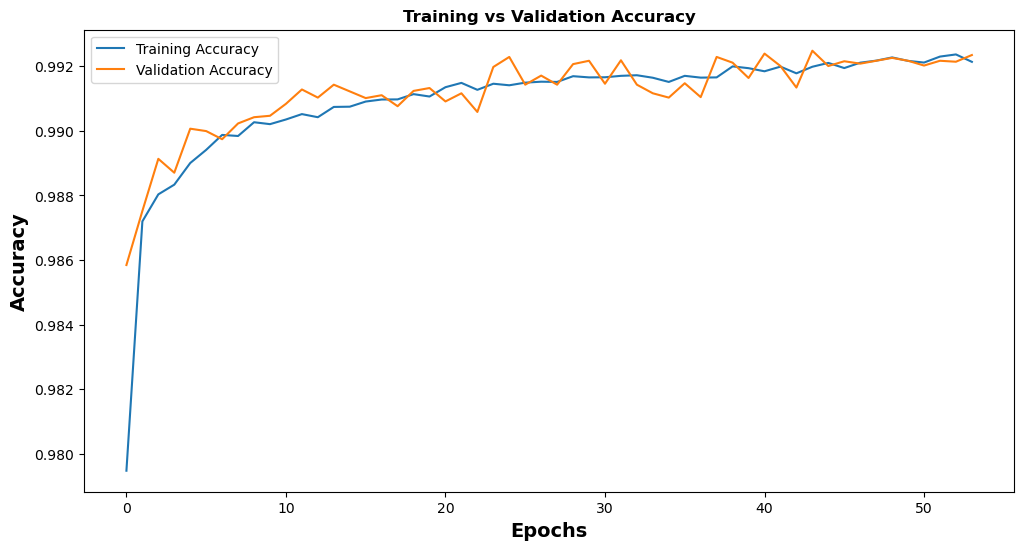

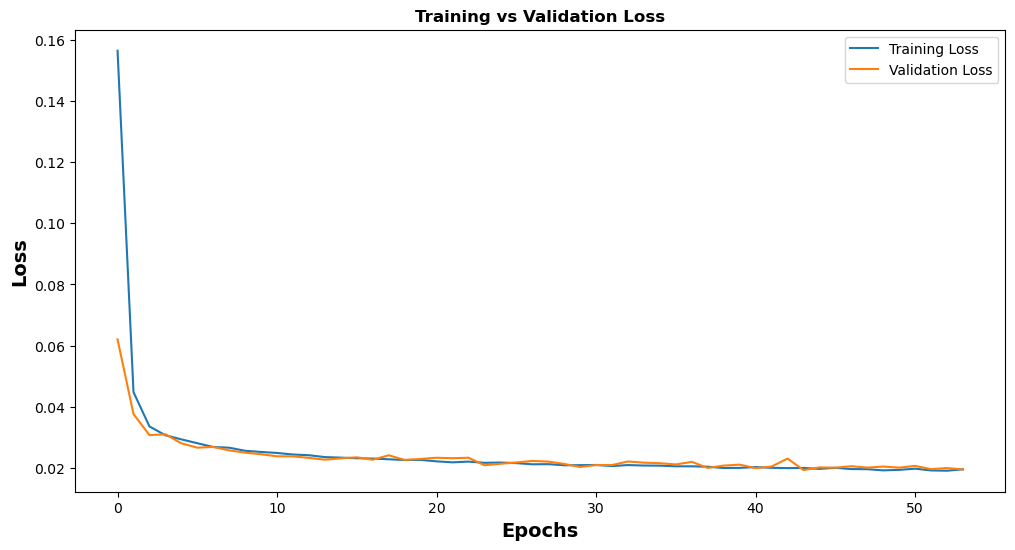

2109/2109 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


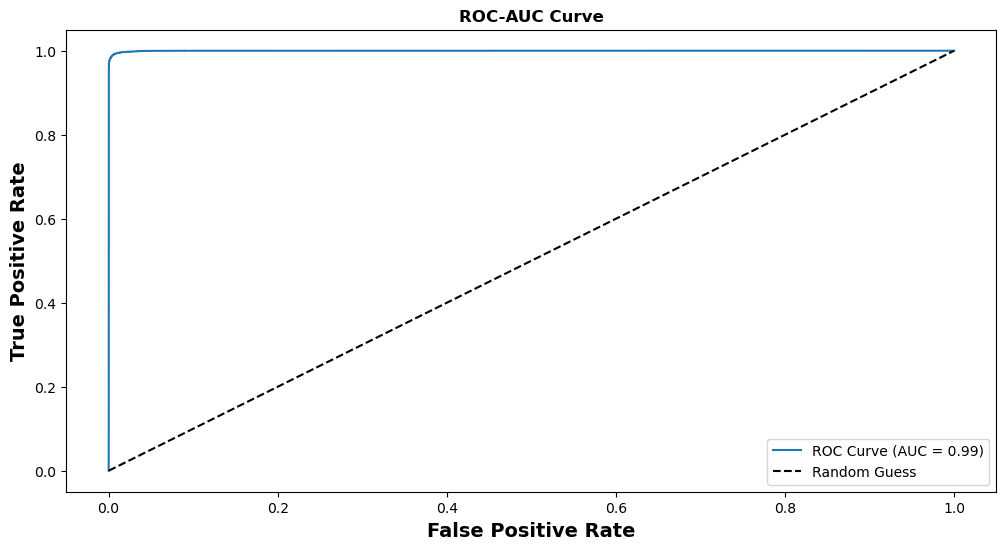

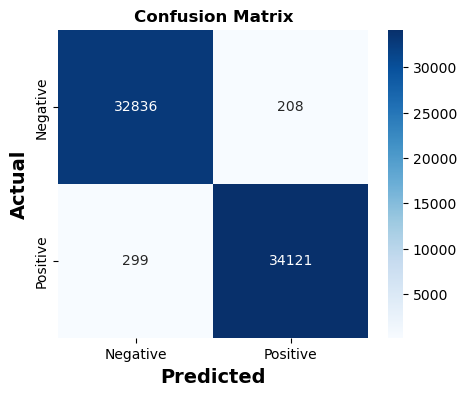

                       Name  Accuracy  Precision  Sensitivity  F1 Score  \
0  FFNN + Wide & Deep Model  0.992485   0.993941     0.991313  0.992625   

        MCC  Markedness  Youden's J       FMI        Time  
0  0.984968    0.987646    0.985019  0.992626  308.011874  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score,
    confusion_matrix, roc_curve
)
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Performance DataFrame
performance = pd.DataFrame(columns=['Name', 'Accuracy', 'Precision', 'Sensitivity', 'F1 Score', 'MCC', 'Markedness', "Youden's J", 'FMI', 'Time'])

X = df.drop(columns=[LABEL]).values
y = df[LABEL].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def markedness(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    return precision + specificity - 1

def youdens_j(y_true, y_pred):
    sensitivity = recall_score(y_true, y_pred)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    return sensitivity + specificity - 1

def fowlkes_mallows_index(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return np.sqrt(precision * recall)
    
# Build Feed-Forward Neural Network + Wide & Deep Model
def build_wide_deep_model(input_dim):
    wide_input = Input(shape=(input_dim,))
    wide_output = Dense(1, activation='sigmoid')(wide_input)

    deep_input = Input(shape=(input_dim,))
    deep_layer_1 = Dense(64, activation='relu')(deep_input)
    deep_layer_2 = Dense(32, activation='relu')(deep_layer_1)
    deep_output = Dense(1, activation='sigmoid')(deep_layer_2)

    concatenated = Concatenate()([wide_output, deep_output])
    final_output = Dense(1, activation='sigmoid')(concatenated)

    model = Model(inputs=[wide_input, deep_input], outputs=final_output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize Model
model = build_wide_deep_model(X_train_scaled.shape[1])

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training the model with validation and hyperparameter tuning
start_time = time.time()

history = model.fit(
    [X_train_scaled, X_train_scaled], y_train,
    validation_data=([X_test_scaled, X_test_scaled], y_test),
    epochs=100, batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

end_time = time.time()
elapsed_time = end_time - start_time

# Predicting and calculating performance metrics
y_pred = (model.predict([X_test_scaled, X_test_scaled]) > 0.5).astype("int32")

# Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
markedness =  markedness(y_test, y_pred)
youden_j = youdens_j(y_test, y_pred)
fmi = fowlkes_mallows_index(y_test, y_pred)

# Plotting graphs
# 1. Training vs Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy', fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# 2. Training vs Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss', fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# 3. ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict([X_test_scaled, X_test_scaled]))
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC-AUC Curve', fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# 4. Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=14, fontweight='bold')
plt.show()



# Store results in the performance DataFrame
new_row = pd.DataFrame([{
    'Name': 'FFNN + Wide & Deep Model',
    'Accuracy': accuracy,
    'Precision': precision,
    'Sensitivity': sensitivity,
    'F1 Score': f1,
    'MCC': mcc,
    'Markedness': markedness,
    "Youden's J": youden_j,
    'FMI': fmi,
    'Time': elapsed_time
}])

performance = pd.concat([performance, new_row], ignore_index=True)
print(performance)
